In [ ]:
import sys
!{sys.executable} -m pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 11.1 MB 597 kB/s eta 0:00:01
     |████████████████████████████████| 30.3 MB 916 kB/s eta 0:00:01
     |████████████████████████████████| 309 kB 9.9 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [12]:
import sys
!{sys.executable} -m pip install pandas matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [ ]:
# Check for missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0])

# Check for duplicates
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")

# Check for outliers
def outlier_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum(), lower, upper

for col in ['Sales', 'Profit']:
    count, lower, upper = outlier_iqr(df[col])
    print(f"Outliers in {col}: {count} (outside [{lower:.2f}, {upper:.2f}])")

# Cleaning decisions (example: drop duplicates, keep outliers for business context)
df_clean = df.drop_duplicates()
print(f"Rows after dropping duplicates: {df_clean.shape[0]}")

Missing values per column:
Series([], dtype: int64)
Duplicate rows: 0
Outliers in Sales: 1167 (outside [-271.71, 498.93])
Outliers in Profit: 1881 (outside [-39.72, 70.82])
Rows after dropping duplicates: 9994


## Monthly/Quarterly Trend Analysis
- Analyze seasonality in sales, profit, and margin
- Visualize monthly and quarterly trends

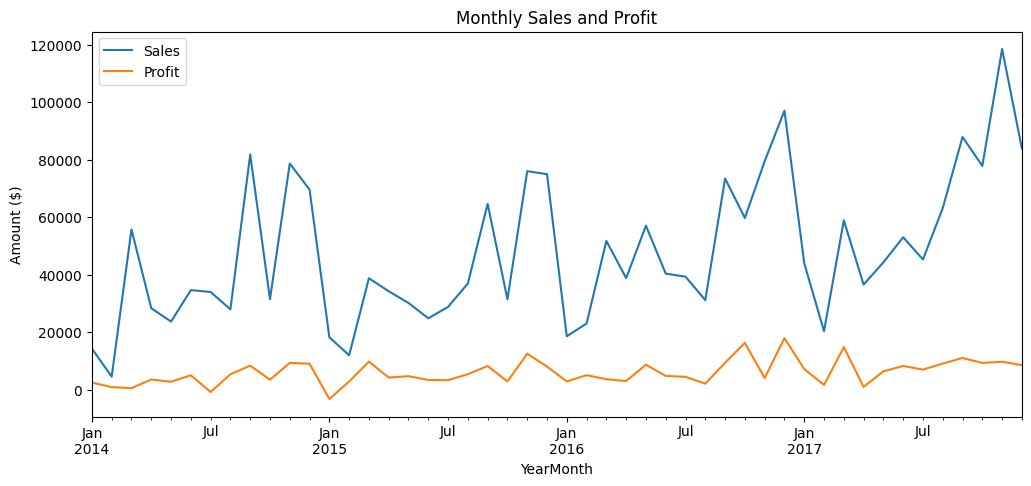

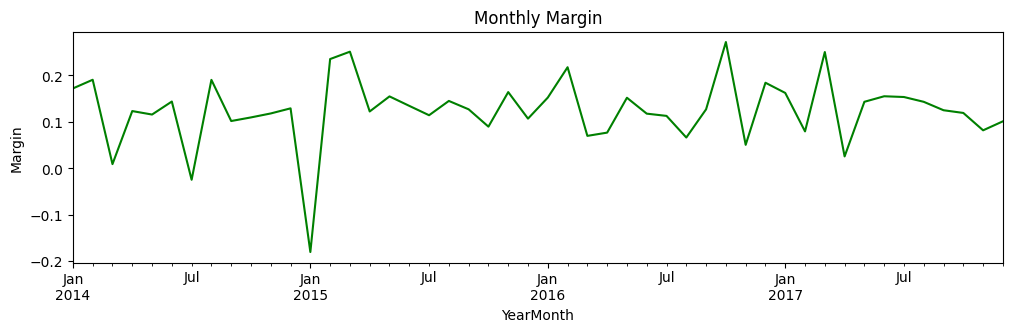

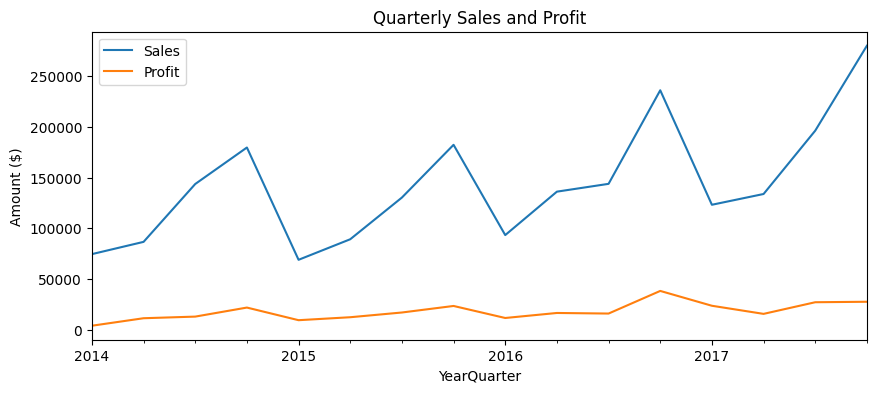

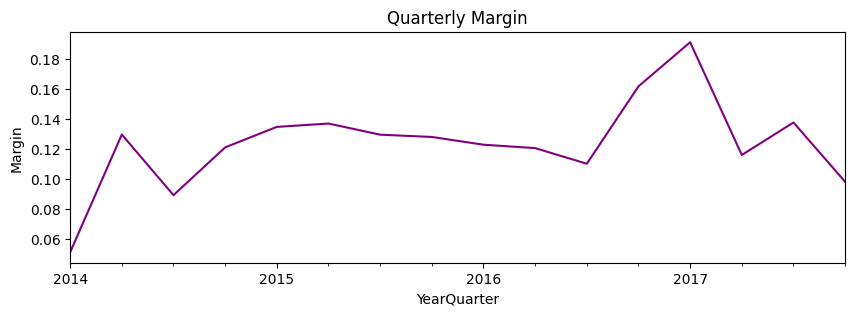

In [30]:
# Ensure date column is datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

# Monthly trend
df['YearMonth'] = df['Order Date'].dt.to_period('M')
monthly = df.groupby('YearMonth').agg({'Sales': 'sum', 'Profit': 'sum'})
monthly['Margin'] = monthly['Profit'] / monthly['Sales']

monthly.index = monthly.index.to_timestamp()
monthly[['Sales', 'Profit']].plot(figsize=(12,5), title='Monthly Sales and Profit')
plt.ylabel('Amount ($)')
plt.show()

monthly['Margin'].plot(figsize=(12,3), title='Monthly Margin', color='green')
plt.ylabel('Margin')
plt.show()

# Quarterly trend
df['YearQuarter'] = df['Order Date'].dt.to_period('Q')
quarterly = df.groupby('YearQuarter').agg({'Sales': 'sum', 'Profit': 'sum'})
quarterly['Margin'] = quarterly['Profit'] / quarterly['Sales']

quarterly.index = quarterly.index.to_timestamp()
quarterly[['Sales', 'Profit']].plot(figsize=(10,4), title='Quarterly Sales and Profit')
plt.ylabel('Amount ($)')
plt.show()

quarterly['Margin'].plot(figsize=(10,3), title='Quarterly Margin', color='purple')
plt.ylabel('Margin')
plt.show()

## Discount Sensitivity Simulation
- Estimate profit change if discount is capped (e.g., at 20% or 30%) by category/region

In [31]:
# Simulate capping discount at 20% and 30%
def simulate_discount_cap(df, cap):
    df_sim = df.copy()
    df_sim['Discount_Capped'] = df_sim['Discount'].clip(upper=cap)
    # Assume profit is linearly related to discount reduction
    df_sim['Profit_Sim'] = df_sim['Profit'] + (df_sim['Discount'] - df_sim['Discount_Capped']) * df_sim['Sales']
    return df_sim

for cap in [0.2, 0.3]:
    print(f"\n--- Discount cap at {int(cap*100)}% ---")
    df_sim = simulate_discount_cap(df, cap)
    # By Category
    cat = df_sim.groupby('Category').agg({'Sales': 'sum', 'Profit': 'sum', 'Profit_Sim': 'sum'})
    cat['Profit Change (%)'] = 100 * (cat['Profit_Sim'] - cat['Profit']) / cat['Profit']
    display(cat[['Sales', 'Profit', 'Profit_Sim', 'Profit Change (%)']])
    # By Region
    reg = df_sim.groupby('Region').agg({'Sales': 'sum', 'Profit': 'sum', 'Profit_Sim': 'sum'})
    reg['Profit Change (%)'] = 100 * (reg['Profit_Sim'] - reg['Profit']) / reg['Profit']
    display(reg[['Sales', 'Profit', 'Profit_Sim', 'Profit Change (%)']])


--- Discount cap at 20% ---


,Sales,Profit,Profit_Sim,Profit Change (%)
Category,,,,
Furniture,741999.7953,18451.2728,50814.259556,175.397042
Office Supplies,719047.0320,122490.8008,143948.749900,17.518009
Technology,836154.0330,145454.9481,179172.529700,23.180773


,Sales,Profit,Profit_Sim,Profit Change (%)
Region,,,,
Central,501239.8908,39706.3625,66649.685956,67.856439
East,678781.2400,91522.7800,123387.098900,34.815724
South,391721.9050,46749.4303,68380.842900,46.270965
West,725457.8245,108418.4489,115517.911400,6.548205



--- Discount cap at 30% ---


,Sales,Profit,Profit_Sim,Profit Change (%)
Category,,,,
Furniture,741999.7953,18451.2728,31299.185476,69.631579
Office Supplies,719047.0320,122490.8008,139996.435200,14.291387
Technology,836154.0330,145454.9481,166362.903500,14.374180


,Sales,Profit,Profit_Sim,Profit Change (%)
Region,,,,
Central,501239.8908,39706.3625,53736.276076,35.334170
East,678781.2400,91522.7800,108800.059200,18.877573
South,391721.9050,46749.4303,61309.143600,31.144151
West,725457.8245,108418.4489,113813.045300,4.975718


## Root-Cause Matrix: State x Sub-Category x Discount Band
- Heatmap/table to show where losses are concentrated

In [34]:
import seaborn as sns
# Prepare pivot table for losses
pivot = df.pivot_table(
    index='State',
    columns=['Sub-Category', 'Discount Band'],
    values='Profit',
    aggfunc='sum',
    fill_value=0
)
# Show top 10 states with most negative total profit
top_loss_states = df.groupby('State')['Profit'].sum().sort_values().head(10).index
pivot_top = pivot.loc[top_loss_states]
display(pivot_top)



/var/folders/1p/kphdnjgj5y9d6dgs06ftn_vw0000gn/T/ipykernel_1416/2830767503.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


Sub-Category   Accessories                                               \
Discount Band           0% 0-10% 10-20%     20-30% 30-40% 40-50% 50-60%   
State                                                                     
Texas                  0.0   0.0    0.0  1105.8501    0.0    0.0    0.0   
Ohio                   0.0   0.0    0.0  1452.8701    0.0    0.0    0.0   
Pennsylvania           0.0   0.0    0.0   898.9687    0.0    0.0    0.0   
Illinois               0.0   0.0    0.0   981.8644    0.0    0.0    0.0   
North Carolina         0.0   0.0    0.0   821.0744    0.0    0.0    0.0   
Colorado               0.0   0.0    0.0   224.5594    0.0    0.0    0.0   
Tennessee              0.0   0.0    0.0    35.2185    0.0    0.0    0.0   
Arizona                0.0   0.0    0.0   224.7694    0.0    0.0    0.0   
Florida                0.0   0.0    0.0   750.0683    0.0    0.0    0.0   
Oregon                 0.0   0.0    0.0   152.1385    0.0    0.0    0.0   

Sub-Category               Appliances  ... Supplies Tables               \
Discount Band  60-70% 70%+         0%  ...     70%+     0% 0-10% 10-20%   
State                                  ...                                
Texas             0.0  0.0        0.0  ...      0.0    0.0   0.0    0.0   
Ohio              0.0  0.0        0.0  ...      0.0    0.0   0.0    0.0   
Pennsylvania      0.0  0.0        0.0  ...      0.0    0.0   0.0    0.0   
Illinois          0.0  0.0        0.0  ...      0.0    0.0   0.0    0.0   
North Carolina    0.0  0.0        0.0  ...      0.0    0.0   0.0    0.0   
Colorado          0.0  0.0        0.0  ...      0.0    0.0   0.0    0.0   
Tennessee         0.0  0.0        0.0  ...      0.0    0.0   0.0    0.0   
Arizona           0.0  0.0        0.0  ...      0.0    0.0   0.0    0.0   
Florida           0.0  0.0        0.0  ...      0.0    0.0   0.0    0.0   
Oregon            0.0  0.0        0.0  ...      0.0    0.0   0.0    0.0   

Sub-Category                                                        
Discount Band  20-30%     30-40%     40-50%     50-60% 60-70% 70%+  
State                                                               
Texas             0.0 -2216.6766     0.0000     0.0000    0.0  0.0  
Ohio              0.0     0.0000 -2715.3345     0.0000    0.0  0.0  
Pennsylvania      0.0     0.0000 -2588.7538     0.0000    0.0  0.0  
Illinois          0.0     0.0000     0.0000 -4309.7447    0.0  0.0  
North Carolina    0.0     0.0000 -3684.2539     0.0000    0.0  0.0  
Colorado          0.0     0.0000     0.0000  -974.8754    0.0  0.0  
Tennessee         0.0     0.0000 -2663.4138     0.0000    0.0  0.0  
Arizona           0.0     0.0000     0.0000 -2281.8701    0.0  0.0  
Florida           0.0     0.0000 -2493.1111     0.0000    0.0  0.0  
Oregon            0.0     0.0000     0.0000 -1048.8971    0.0  0.0  

[10 rows x 153 columns]

## Simple Predictive Model: Profit/Loss Classification
- Classify whether an order will be profit or loss
- Show feature importance

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Prepare order-level data
order_df = df.groupby('Order ID').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'mean',
    'Quantity': 'sum',
    'Ship Days': 'mean',
    'Category': lambda x: x.mode()[0],
    'Region': lambda x: x.mode()[0],
    'Segment': lambda x: x.mode()[0],
    'Ship Mode': lambda x: x.mode()[0]
}).reset_index()

# Target: 1 if profit > 0 else 0
order_df['ProfitFlag'] = (order_df['Profit'] > 0).astype(int)

# Encode categorical features
for col in ['Category', 'Region', 'Segment', 'Ship Mode']:
    order_df[col] = LabelEncoder().fit_transform(order_df[col])

X = order_df[['Sales', 'Discount', 'Quantity', 'Ship Days', 'Category', 'Region', 'Segment', 'Ship Mode']]
y = order_df['ProfitFlag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check if model is defined and train if not
try:
    clf
except NameError:
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

# Feature importance
importances = clf.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]
print('Feature importances:')
for f in range(len(features)):
    print(f"{features[indices[f]]}: {importances[indices[f]]:.3f}")

              precision    recall  f1-score   support

           0       0.77      0.73      0.75       205
           1       0.93      0.94      0.94       797

    accuracy                           0.90      1002
   macro avg       0.85      0.84      0.84      1002
weighted avg       0.90      0.90      0.90      1002

Confusion Matrix:
[[150  55]
 [ 45 752]]
Feature importances:
Discount: 0.584
Sales: 0.162
Quantity: 0.086
Region: 0.047
Ship Days: 0.044
Category: 0.032
Segment: 0.026
Ship Mode: 0.019


In [28]:
# Missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0])

# Duplicates
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")

# Outlier check (IQR method for Sales and Profit)
def outlier_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum(), lower, upper

for col in ['Sales', 'Profit']:
    count, lower, upper = outlier_iqr(df[col])
    print(f"Outliers in {col}: {count} (outside [{lower:.2f}, {upper:.2f}])")

# Cleaning decisions (example: drop duplicates, keep outliers for business context)
df_clean = df.drop_duplicates()
print(f"Rows after dropping duplicates: {df_clean.shape[0]}")

Missing values per column:
Series([], dtype: int64)
Duplicate rows: 0
Outliers in Sales: 1167 (outside [-271.71, 498.93])
Outliers in Profit: 1881 (outside [-39.72, 70.82])
Rows after dropping duplicates: 9994


In [13]:
import pandas as pd

df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [15]:
df.groupby("Region")["Sales"].sum()

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64

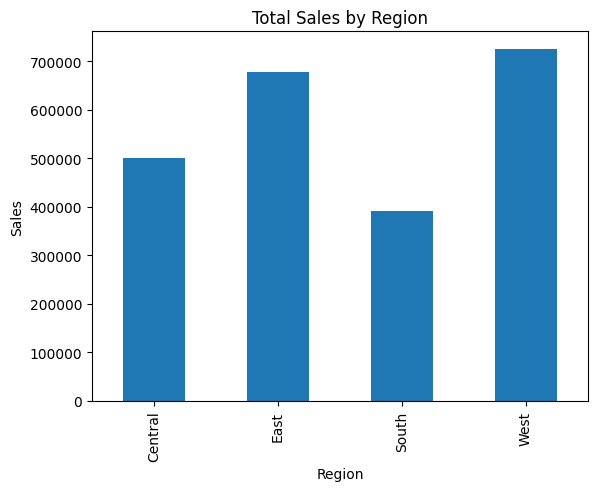

In [17]:
import matplotlib.pyplot as plt

sales_by_region = df.groupby("Region")["Sales"].sum()

sales_by_region.plot(kind="bar")

plt.title("Total Sales by Region")
plt.ylabel("Sales")
plt.show()

In [18]:
# Data Cleaning
# 1. Check for missing values
missing_values = df.isnull().sum()
print('Missing values in each column:')
print(missing_values)

# 2. Check for duplicates
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')

# 3. Check data types
print('Data types of each column:')
print(df.dtypes)

Missing values in each column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
Number of duplicate rows: 0
Data types of each column:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Pr

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


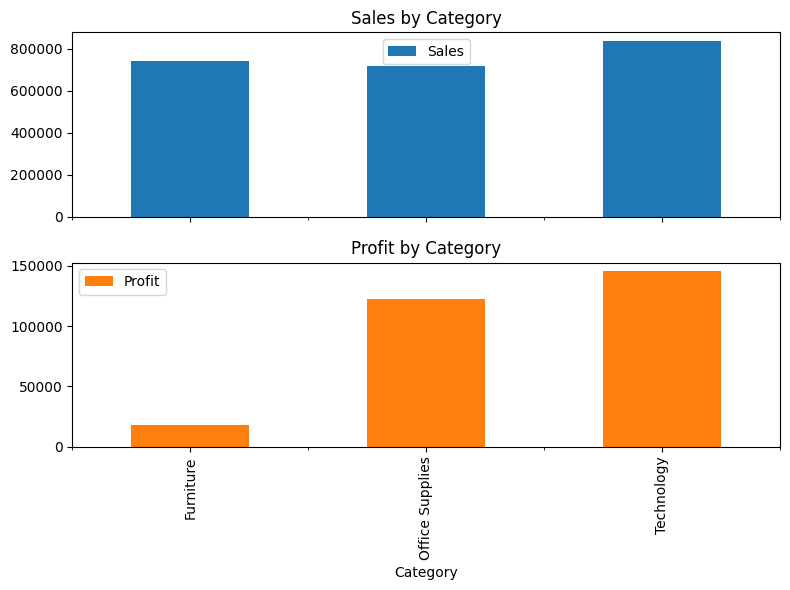

,Sales,Profit
Sub-Category,,
Phones,330007.0540,44515.7306
Chairs,328449.1030,26590.1663
Storage,223843.6080,21278.8264
Tables,206965.5320,-17725.4811
Binders,203412.7330,30221.7633
Machines,189238.6310,3384.7569
Accessories,167380.3180,41936.6357
Copiers,149528.0300,55617.8249
Bookcases,114879.9963,-3472.5560


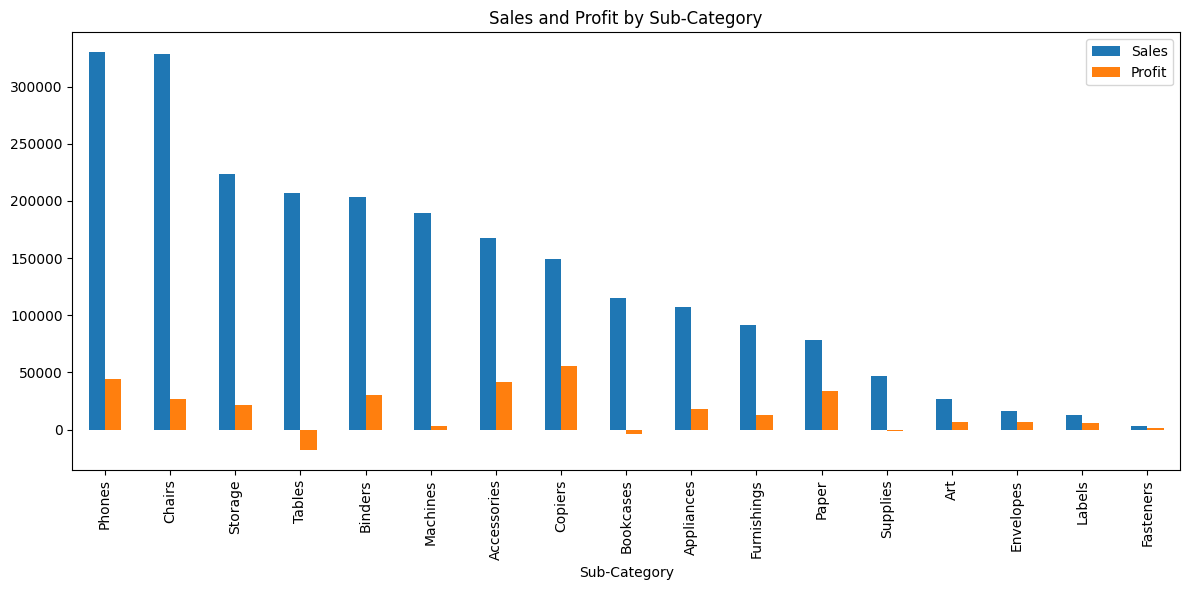

In [20]:
# Summary statistics
display(df.describe())

# Sales and Profit by Category
category_sales = df.groupby('Category')[['Sales', 'Profit']].sum()
display(category_sales)
category_sales.plot(kind='bar', y=['Sales', 'Profit'], subplots=True, layout=(2,1), figsize=(8,6), title=['Sales by Category', 'Profit by Category'])
plt.tight_layout()
plt.show()

# Sales and Profit by Sub-Category
subcat_sales = df.groupby('Sub-Category')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
display(subcat_sales)
subcat_sales[['Sales', 'Profit']].plot(kind='bar', figsize=(12,6), title='Sales and Profit by Sub-Category')
plt.tight_layout()
plt.show()

In [21]:
# Parse date columns
for col in ['Order Date', 'Ship Date']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Create Ship Days
if 'Ship Days' not in df.columns:
    df['Ship Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Confirm schema and data types
display(df.info())
display(df.head())
display(df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

None

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Ship Days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Ship Days
count,9994.000000,9994,9994,9994,9994,9994,9994,9994,9994,9994,...,9994,9994,9994,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
unique,NaN,5009,NaN,NaN,4,793,793,3,1,531,...,4,1862,3,17,1850,NaN,NaN,NaN,NaN,NaN
top,NaN,CA-2017-100111,NaN,NaN,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,...,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN,NaN,NaN,NaN,NaN
freq,NaN,14,NaN,NaN,5968,37,37,5191,9994,915,...,3203,19,6026,1523,48,NaN,NaN,NaN,NaN,NaN
mean,4997.500000,NaN,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,229.858001,3.789574,0.156203,28.656896,3.958175
min,1.000000,NaN,2014-01-03 00:00:00,2014-01-07 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000,0.000000
25%,2499.250000,NaN,2015-05-23 00:00:00,2015-05-27 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,17.280000,2.000000,0.000000,1.728750,3.000000
50%,4997.500000,NaN,2016-06-26 00:00:00,2016-06-29 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,54.490000,3.000000,0.200000,8.666500,4.000000
75%,7495.750000,NaN,2017-05-14 00:00:00,2017-05-18 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,209.940000,5.000000,0.200000,29.364000,5.000000
max,9994.000000,NaN,2017-12-30 00:00:00,2018-01-05 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,22638.480000,14.000000,0.800000,8399.976000,7.000000


In [22]:
# Compute total Sales, total Profit, and overall Margin

total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
overall_margin = total_profit / total_sales if total_sales != 0 else float('nan')

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Overall Margin: {overall_margin:.2%}")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Overall Margin: 12.47%


,Sales,Profit,Margin
Year,,,
2014,484247.4981,49543.9741,0.102311
2015,470532.5090,61618.6037,0.130955
2016,609205.5980,81795.1743,0.134265
2017,733215.2552,93439.2696,0.127438


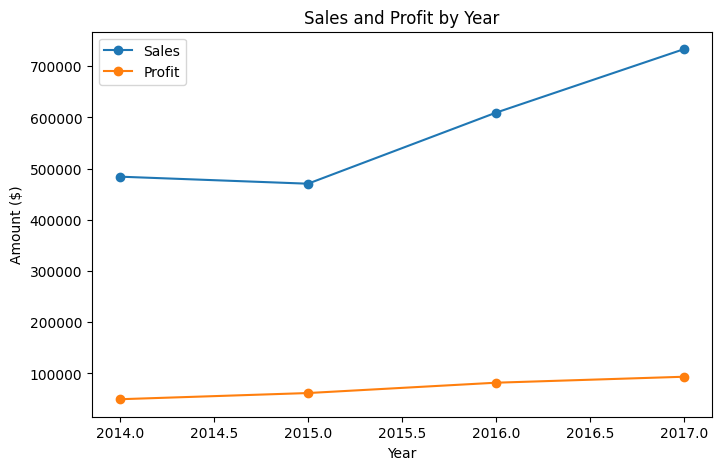

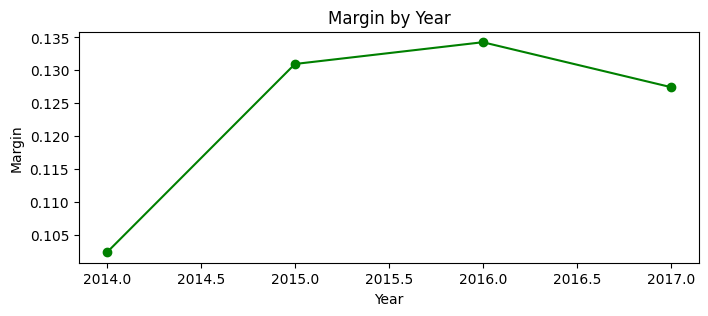

In [23]:
# Extract year from Order Date
if 'Year' not in df.columns:
    df['Year'] = df['Order Date'].dt.year

# Group by year and calculate KPIs
yearly = df.groupby('Year').agg({'Sales': 'sum', 'Profit': 'sum'})
yearly['Margin'] = yearly['Profit'] / yearly['Sales']

display(yearly)

# Plot trends
fig, ax1 = plt.subplots(figsize=(8,5))
yearly[['Sales', 'Profit']].plot(ax=ax1, marker='o')
ax1.set_ylabel('Amount ($)')
ax1.set_title('Sales and Profit by Year')
plt.show()

fig, ax2 = plt.subplots(figsize=(8,3))
yearly['Margin'].plot(ax=ax2, marker='o', color='green')
ax2.set_ylabel('Margin')
ax2.set_title('Margin by Year')
plt.show()

In [24]:
# Helper function to summarize segment KPIs
def segment_kpi(df, group_col):
    seg = df.groupby(group_col).agg({'Sales': 'sum', 'Profit': 'sum'})
    seg['Margin'] = seg['Profit'] / seg['Sales']
    seg['Revenue Share'] = seg['Sales'] / df['Sales'].sum()
    seg['Profit Share'] = seg['Profit'] / df['Profit'].sum()
    return seg.sort_values('Sales', ascending=False)

# Analyze by Category, Sub-Category, Region, State, City, Segment
for col in ['Category', 'Sub-Category', 'Region', 'State', 'City', 'Segment']:
    print(f'\n---- {col} ----')
    display(segment_kpi(df, col))


---- Category ----


,Sales,Profit,Margin,Revenue Share,Profit Share
Category,,,,,
Technology,836154.0330,145454.9481,0.173957,0.363988,0.507879
Furniture,741999.7953,18451.2728,0.024867,0.323002,0.064426
Office Supplies,719047.0320,122490.8008,0.170352,0.313010,0.427696



---- Sub-Category ----


,Sales,Profit,Margin,Revenue Share,Profit Share
Sub-Category,,,,,
Phones,330007.0540,44515.7306,0.134893,0.143656,0.155434
Chairs,328449.1030,26590.1663,0.080957,0.142978,0.092844
Storage,223843.6080,21278.8264,0.095061,0.097442,0.074298
Tables,206965.5320,-17725.4811,-0.085645,0.090095,-0.061891
Binders,203412.7330,30221.7633,0.148574,0.088548,0.105524
Machines,189238.6310,3384.7569,0.017886,0.082378,0.011818
Accessories,167380.3180,41936.6357,0.250547,0.072863,0.146428
Copiers,149528.0300,55617.8249,0.371956,0.065091,0.194198
Bookcases,114879.9963,-3472.5560,-0.030228,0.050009,-0.012125



---- Region ----


...

,Sales,Profit,Margin,Revenue Share,Profit Share
State,,,,,
California,457687.6315,76381.3871,0.166885,0.199237,0.266698
New York,310876.2710,74038.5486,0.238161,0.135328,0.258517
Texas,170188.0458,-25729.3563,-0.151182,0.074085,-0.089838
Washington,138641.2700,33402.6517,0.240929,0.060352,0.116631
Pennsylvania,116511.9140,-15559.9603,-0.133548,0.050719,-0.054330
Florida,89473.7080,-3399.3017,-0.037992,0.038949,-0.011869
Illinois,80166.1010,-12607.8870,-0.157272,0.034897,-0.044022
Ohio,78258.1360,-16971.3766,-0.216864,0.034067,-0.059258
Michigan,76269.6140,24463.1876,0.320746,0.033201,0.085417



---- City ----


,Sales,Profit,Margin,Revenue Share,Profit Share
City,,,,,
New York City,256368.161,62036.9837,0.241984,1.116002e-01,2.166118e-01
Los Angeles,175851.341,30440.7579,0.173105,7.655027e-02,1.062887e-01
Seattle,119540.742,29156.0967,0.243901,5.203757e-02,1.018031e-01
San Francisco,112669.092,17507.3854,0.155388,4.904625e-02,6.112977e-02
Philadelphia,109077.013,-13837.7674,-0.126862,4.748258e-02,-4.831673e-02
...,...,...,...,...,...
Ormond Beach,2.808,-1.9656,-0.700000,1.222357e-06,-6.863200e-06
Pensacola,2.214,-1.4760,-0.666667,9.637816e-07,-5.153685e-06
Jupiter,2.064,0.1548,0.075000,8.984848e-07,5.405084e-07



---- Segment ----


,Sales,Profit,Margin,Revenue Share,Profit Share
Segment,,,,,
Consumer,1.161401e+06,134119.2092,0.115481,0.505572,0.468298
Corporate,7.061464e+05,91979.1340,0.130255,0.307394,0.321160
Home Office,4.296531e+05,60298.6785,0.140343,0.187033,0.210542


/var/folders/1p/kphdnjgj5y9d6dgs06ftn_vw0000gn/T/ipykernel_1416/2721236349.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_kpi = df.groupby('Discount Band').agg({'Sales': 'sum', 'Profit': 'sum', 'Discount': 'count'})


,Sales,Profit,Order Count,Margin
Discount Band,,,,
0%,1.087908e+06,320987.6032,4798,0.295050
0-10%,0.000000e+00,0.0000,0,NaN
10-20%,8.192787e+04,10448.1685,146,0.127529
20-30%,7.645944e+05,90337.3060,3657,0.118151
30-40%,1.177201e+05,-12760.4151,254,-0.108396
40-50%,1.219028e+05,-25550.1615,217,-0.209595
50-60%,5.891854e+04,-20506.4281,66,-0.348047
60-70%,6.644700e+03,-5944.6552,138,-0.894646
70%+,5.758404e+04,-70614.3961,718,-1.226284


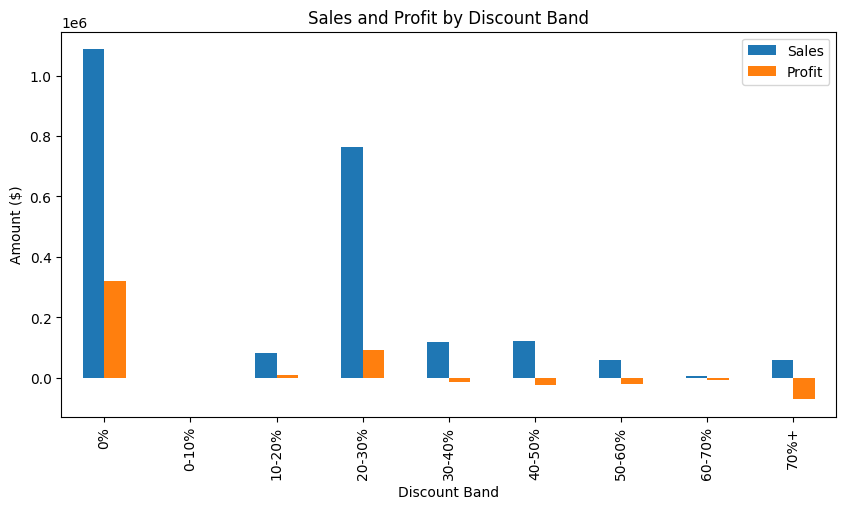

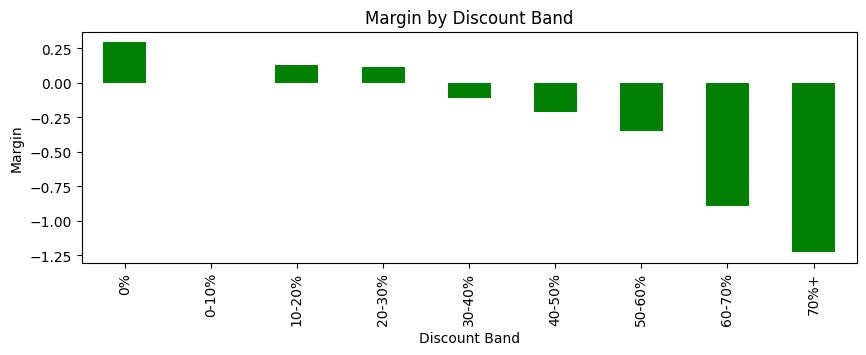

Orders with Discount >= 10%: 5196
Orders with Discount >= 30%: 1393
Orders with Discount >= 50%: 922
Correlation between Discount and Profit: -0.22


In [25]:
# Bin discounts into bands
bins = [0, 0.001, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 1.0]
labels = ['0%', '0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70%+']
df['Discount Band'] = pd.cut(df['Discount'], bins=bins, labels=labels, include_lowest=True, right=False)

discount_kpi = df.groupby('Discount Band').agg({'Sales': 'sum', 'Profit': 'sum', 'Discount': 'count'})
discount_kpi['Margin'] = discount_kpi['Profit'] / discount_kpi['Sales']
discount_kpi.rename(columns={'Discount': 'Order Count'}, inplace=True)
display(discount_kpi)

# Plot sales, profit, and margin by discount band
discount_kpi[['Sales', 'Profit']].plot(kind='bar', figsize=(10,5), title='Sales and Profit by Discount Band')
plt.ylabel('Amount ($)')
plt.show()
discount_kpi['Margin'].plot(kind='bar', color='green', figsize=(10,3), title='Margin by Discount Band')
plt.ylabel('Margin')
plt.show()

# Threshold checks
for thresh in [0.1, 0.3, 0.5]:
    count = (df['Discount'] >= thresh).sum()
    print(f"Orders with Discount >= {int(thresh*100)}%: {count}")

# Correlation between Discount and Profit
corr = df['Discount'].corr(df['Profit'])
print(f"Correlation between Discount and Profit: {corr:.2f}")

,,Sales,Profit,Order Count
State,Sub-Category,,,
Texas,Binders,9042.676,-14705.0738,153
Ohio,Machines,8978.238,-11770.9447,8
Illinois,Binders,4538.546,-7204.3242,80
Texas,Appliances,2407.814,-6147.2225,47
North Carolina,Machines,12620.655,-5384.8086,4
Pennsylvania,Binders,6266.058,-4570.9750,98
New York,Tables,13779.018,-4535.6408,28
Colorado,Machines,3313.689,-4384.2554,3
Illinois,Tables,6550.670,-4309.7447,18


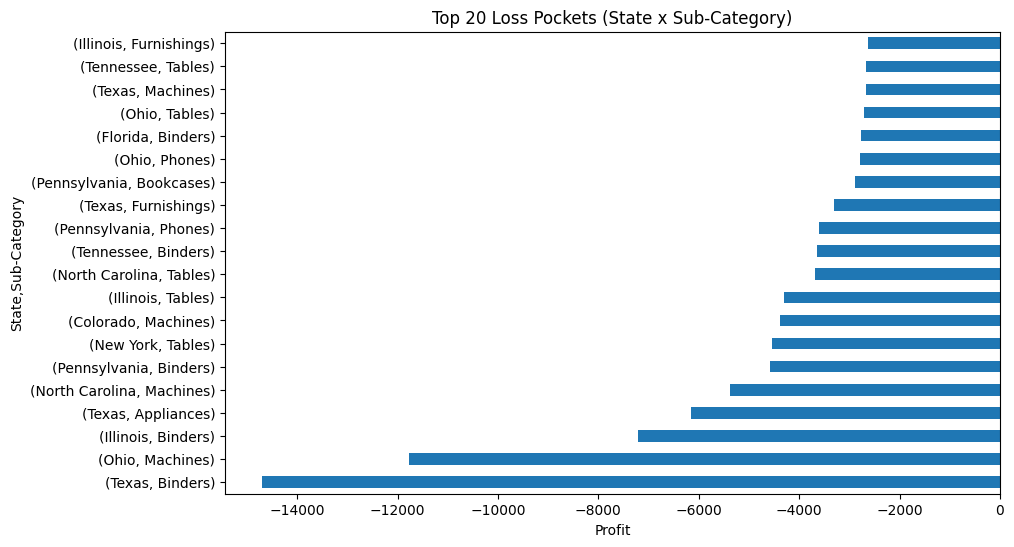

In [26]:
# Find State x Sub-Category combinations with negative profit
loss_pockets = df.groupby(['State', 'Sub-Category']).agg({'Sales': 'sum', 'Profit': 'sum', 'Order ID': 'count'})
loss_pockets = loss_pockets[loss_pockets['Profit'] < 0].sort_values('Profit')
loss_pockets.rename(columns={'Order ID': 'Order Count'}, inplace=True)
display(loss_pockets.head(20))

# Visualize top loss pockets
if not loss_pockets.empty:
    loss_pockets['Profit'].head(20).plot(kind='barh', figsize=(10,6), title='Top 20 Loss Pockets (State x Sub-Category)')
    plt.xlabel('Profit')
    plt.show()

Loss-making orders: 1022 of 5009 (20.4%)
Customers needed for 80% of total profit: 153 of 793 (19.3%)


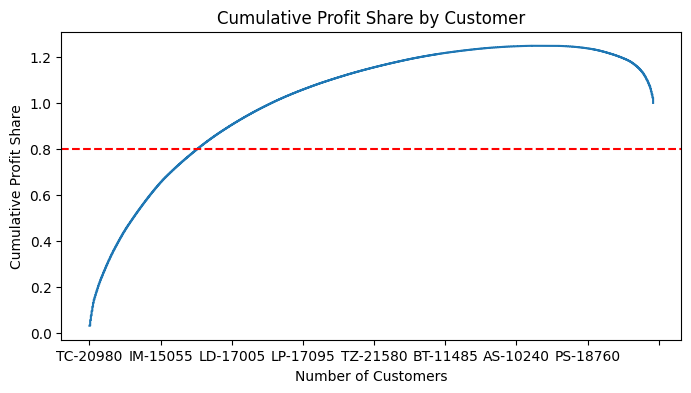

In [27]:
# Order-level profitability
order_profit = df.groupby('Order ID')['Profit'].sum()
loss_orders = (order_profit < 0).sum()
total_orders = order_profit.shape[0]
print(f"Loss-making orders: {loss_orders} of {total_orders} ({loss_orders/total_orders:.1%})")

# Pareto-style customer concentration
customer_profit = df.groupby('Customer ID')['Profit'].sum().sort_values(ascending=False)
cum_profit = customer_profit.cumsum() / customer_profit.sum()
num_80pct = (cum_profit < 0.8).sum() + 1
print(f"Customers needed for 80% of total profit: {num_80pct} of {customer_profit.shape[0]} ({num_80pct/customer_profit.shape[0]:.1%})")

# Visualize cumulative profit share
cum_profit.plot(drawstyle='steps-post', figsize=(8,4), title='Cumulative Profit Share by Customer')
plt.axhline(0.8, color='red', linestyle='--')
plt.xlabel('Number of Customers')
plt.ylabel('Cumulative Profit Share')
plt.show()